# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** MUHAMMAD HUSSAIN

**Roll Number:** 023-24-0225

**GitHub Repository:** https://github.com/muhammadhussainbscsf24-wq/ML-LABS

**Duration:** 3 Hours (independent, hands-on)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
Customer churn occurs when existing subscribers discontinue their service with the telecommunications provider. The primary business objective is to identify subscribers at high risk of leaving so the company can intervene early with targeted retention offers. The target variable is `Churn` (`Yes` or `No`).

**Answer 2:**
* **5 Useful Predictors:**
  1. `Contract`: Month-to-month contract holders face no long-term commitment or exit fees, making them significantly more likely to churn.
  2. `tenure`: Newer customers generally have lower brand loyalty and are at a much higher risk of early cancellation.
  3. `InternetService`: Fiber Optic plans carry higher price points, which can drive price-sensitive customers toward competitors.
  4. `MonthlyCharges`: Higher monthly recurring bills place financial strain on subscribers, driving churn.
  5. `TechSupport`: Lack of technical support leads to unresolved service issues and subscriber dissatisfaction.
* **2 Useless Predictors:**
  1. `customerID`: A unique primary key string that carries no predictive behavioral signal and can cause overfitting.
  2. `gender`: A basic demographic trait that does not drive core service utility or subscription cancellation decisions.

**Answer 3:**
1. Do month-to-month contract holders churn at a significantly higher rate compared to subscribers on long-term contracts?
2. Does having active Tech Support lower the churn rate among high-paying Fiber Optic subscribers?

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [2]:
# Task 4 — dataset shape, column names, data types
print("Dataset Shape (Rows, Columns):", df.shape)
print("\n--- Columns & Data Types ---")
df.info()

# Separate numerical and categorical columns (updated for future Pandas compatibility)
num_cols = df.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Dataset Shape (Rows, Columns): (7043, 21)

--- Columns & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-n

In [3]:
# Task 5 — identify identifier columns / wrong data types
print("Identifier Column:", [col for col in df.columns if 'ID' in col])
print("TotalCharges raw data type:", df['TotalCharges'].dtype)
print("Sample TotalCharges values:", df['TotalCharges'].head())

Identifier Column: ['customerID']
TotalCharges raw data type: str
Sample TotalCharges values: 0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [4]:
# Task 6 — unique values in 3 categorical columns
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"Unique values in '{col}':\n{df[col].unique()}\n")

Unique values in 'Contract':
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Unique values in 'InternetService':
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Unique values in 'PaymentMethod':
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



**Observations (Part 2):**
* **Dataset Scope:** 7,043 customer records across 21 columns (20 features + 1 target).
* **Numerical Features:** `tenure`, `MonthlyCharges`, `SeniorCitizen` (binary integer 0/1).
* **Categorical Features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `TotalCharges`, `Churn`.
* **Identifier Column:** `customerID` is a primary key string and carries no predictive value.
* **Data Type Mismatch:** `TotalCharges` is stored as an `object` (string) instead of `float64` due to blank space strings (`" "`).

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_pct})
print(missing_summary)

                  Missing Count  Percentage (%)
customerID                    0             0.0
gender                        0             0.0
SeniorCitizen                 0             0.0
Partner                       0             0.0
Dependents                    0             0.0
tenure                        0             0.0
PhoneService                  0             0.0
MultipleLines                 0             0.0
InternetService               0             0.0
OnlineSecurity                0             0.0
OnlineBackup                  0             0.0
DeviceProtection              0             0.0
TechSupport                   0             0.0
StreamingTV                   0             0.0
StreamingMovies               0             0.0
Contract                      0             0.0
PaperlessBilling              0             0.0
PaymentMethod                 0             0.0
MonthlyCharges                0             0.0
TotalCharges                  0         

In [6]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicate Rows Count:", df.duplicated().sum())
print("Duplicate customerID Count:", df['customerID'].duplicated().sum())

Duplicate Rows Count: 0
Duplicate customerID Count: 0


In [7]:
# Task 9 — investigate a suspicious / invalid value
whitespace_tc = (df['TotalCharges'] == ' ').sum()
print(f"Count of empty whitespace strings in TotalCharges: {whitespace_tc}")

# Inspect rows where TotalCharges is ' '
df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Count of empty whitespace strings in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Answer 7 (which missing-value problems need action, and why):**
Standard `isnull().sum()` reports 0 missing values across all columns. However, `TotalCharges` contains 11 empty space strings (`" "`). This requires action because it forces `TotalCharges` to be treated as text, preventing standard numeric operations and model building.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are different issues. Duplicate rows mean entire customer records are identical across every feature. Duplicate `customerID`s mean primary keys are repeated, which violates primary key database integrity even if feature values differ. In this dataset, both counts are 0.

**Answer 9 (suspicious value found and how):**
Checking `df.dtypes` showed `TotalCharges` was stored as an `object` (string). Checking `(df['TotalCharges'] == ' ').sum()` revealed **11 rows** containing blank whitespace strings. Inspecting these rows showed they all have `tenure = 0`, representing brand-new customers who have not completed a billing cycle.

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text string | Convert column to `float64` | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | Required for numerical analysis and machine learning models. |
| 11 missing values in `TotalCharges` | Impute missing entries with `0.0` | `df['TotalCharges'].fillna(0.0)` | Customers have `tenure = 0`, so their total cumulative bill to date is $0.0. |
| `customerID` non-predictive column | Drop column | `df.drop(columns=['customerID'])` | Unique primary keys add random noise and introduce overfitting risks. |

In [8]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()

# 1. Convert TotalCharges to numeric and handle whitespace missing values
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0.0)

# 2. Drop unique identifier column
if 'customerID' in clean_df.columns:
    clean_df = clean_df.drop(columns=['customerID'])

In [9]:
# Task 11 (continued) — confirm each issue is resolved
print("TotalCharges Data Type:", clean_df['TotalCharges'].dtype)
print("Remaining Missing Values in TotalCharges:", clean_df['TotalCharges'].isnull().sum())
print("Total Missing Values in clean_df:", clean_df.isnull().sum().sum())
print("Total Duplicate Rows in clean_df:", clean_df.duplicated().sum())
print("Cleaned DataFrame Shape:", clean_df.shape)

TotalCharges Data Type: float64
Remaining Missing Values in TotalCharges: 0
Total Missing Values in clean_df: 0
Total Duplicate Rows in clean_df: 22
Cleaned DataFrame Shape: (7043, 20)


## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

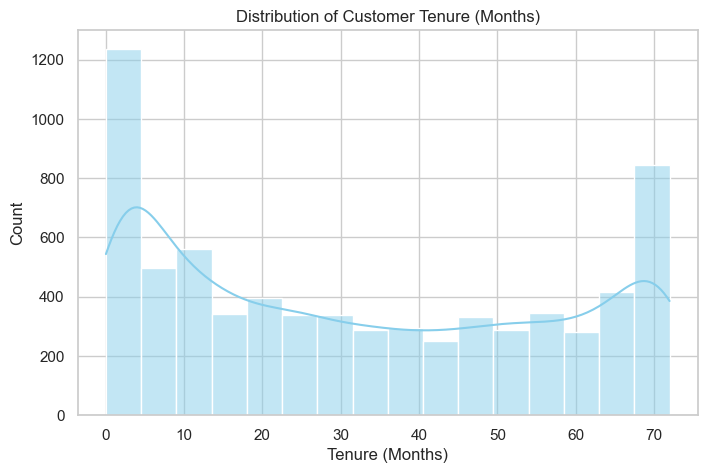

In [10]:
# Task 12 — numerical feature 1: distribution plot
sns.histplot(clean_df['tenure'], kde=True, color='skyblue')
plt.title('Distribution of Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.show()

**Observation:** Customer tenure is strongly bimodal, showing high concentrations at 1 month (new sign-ups) and at 72 months (long-term loyal customers).

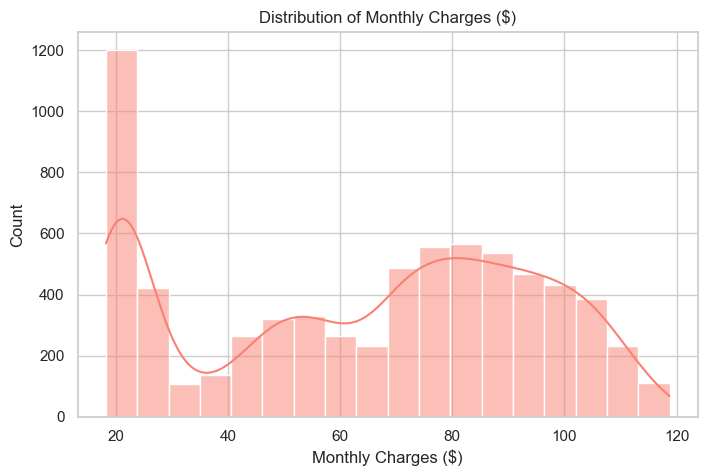

In [11]:
# Task 12 — numerical feature 2: distribution plot
sns.histplot(clean_df['MonthlyCharges'], kde=True, color='salmon')
plt.title('Distribution of Monthly Charges ($)')
plt.xlabel('Monthly Charges ($)')
plt.show()

**Observation:** `MonthlyCharges` shows a large spike near $20 (representing basic phone-only plans), while higher pricing tiers ($70–$110) form a second wide distribution representing bundled internet services.

C:\Users\Areej\AppData\Local\Temp\ipykernel_15956\2922847999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='Contract', palette='Set2')


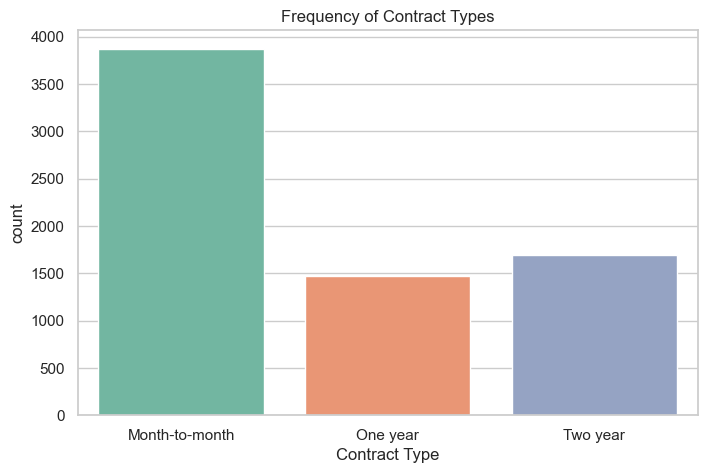

In [12]:
# Task 12 — categorical feature 1: distribution plot
sns.countplot(data=clean_df, x='Contract', palette='Set2')
plt.title('Frequency of Contract Types')
plt.xlabel('Contract Type')
plt.show()

**Observation:** Over 50% of subscribers are on a Month-to-month contract, while One-year and Two-year commitments represent significantly smaller customer portions.

C:\Users\Areej\AppData\Local\Temp\ipykernel_15956\3014895054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='InternetService', palette='Set2')


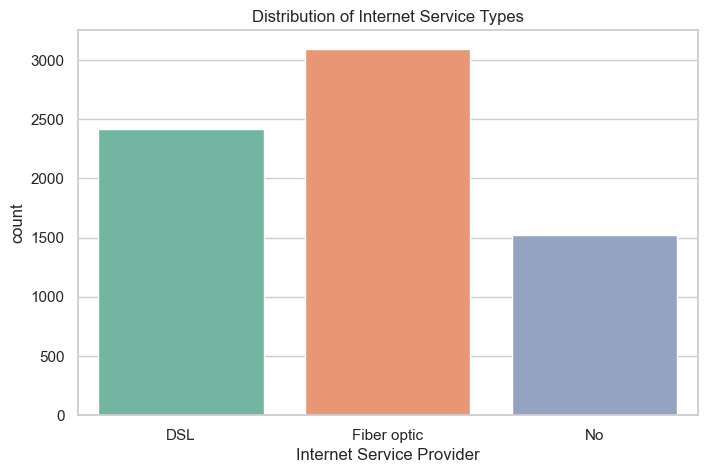

In [13]:
# Task 13 — categorical feature 2: distribution plot
sns.countplot(data=clean_df, x='InternetService', palette='Set2')
plt.title('Distribution of Internet Service Types')
plt.xlabel('Internet Service Provider')
plt.show()

**Observation:** Fiber Optic is the most popular internet service tier, followed closely by DSL, while a smaller segment does not subscribe to internet service.

**Answer 13 (outliers / skew and possible explanation):**
`TotalCharges` exhibits strong right-skewness because total accumulation is inherently tied to `tenure`. No extreme numerical outliers beyond valid operational limits were detected across `tenure` or `MonthlyCharges`.

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

--- Target Class Distribution ---
Non-Churned (No):  5174 (73.46%)
Churned (Yes):      1869 (26.54%)


C:\Users\Areej\AppData\Local\Temp\ipykernel_15956\2858192175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='Churn', palette=['#2ecc71', '#e74c3c'])


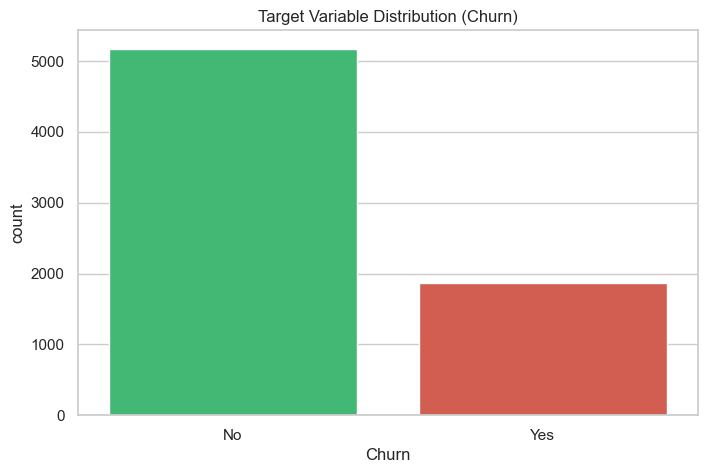

In [14]:
# Task 14 — churn counts and percentages
churn_counts = clean_df['Churn'].value_counts()
churn_pct = clean_df['Churn'].value_counts(normalize=True) * 100

print("--- Target Class Distribution ---")
print(f"Non-Churned (No):  {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"Churned (Yes):      {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")

sns.countplot(data=clean_df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Target Variable Distribution (Churn)')
plt.show()

**Answer 14 (balanced or imbalanced?):**
The target variable is **imbalanced**. Approximately 73.46% of customers are retained (`No`), while 26.54% churned (`Yes`).

**Answer 15 (why imbalance might matter later):**
Class imbalance causes machine learning classifiers to favor the majority class (`No`) to minimize overall classification error. As a result, a model could achieve 73%+ accuracy simply by predicting `No` for every customer, while completely failing to detect actual churning customers (`Yes`).

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

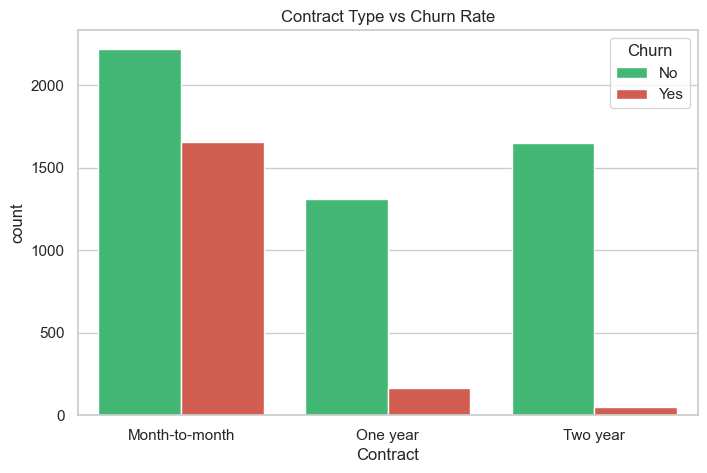

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [15]:
# Task 16 — categorical feature 1 vs Churn
sns.countplot(data=clean_df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn Rate')
plt.show()

print(pd.crosstab(clean_df['Contract'], clean_df['Churn'], normalize='index') * 100)

**Observation:** Month-to-month contract holders show an extremely high churn rate compared to annual contract holders.
**Evidence:** `pd.crosstab` reveals a 42.71% churn rate for Month-to-month contracts versus 2.83% for Two-year contracts.
**Possible Explanation:** Month-to-month customers face no exit fees or contract barriers, making them highly flexible to switch providers.

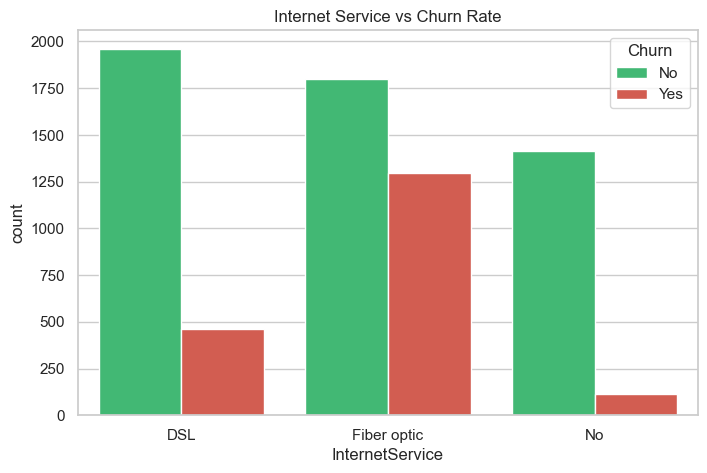

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [16]:
# Task 16 — categorical feature 2 vs Churn
sns.countplot(data=clean_df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Internet Service vs Churn Rate')
plt.show()

print(pd.crosstab(clean_df['InternetService'], clean_df['Churn'], normalize='index') * 100)

**Observation:** Fiber Optic subscribers churn at a much higher rate than DSL or non-internet subscribers.
**Evidence:** 41.89% of Fiber Optic subscribers churned, compared to 18.96% for DSL users.
**Possible Explanation:** Fiber Optic carries higher monthly costs, making customers more sensitive to pricing or service disruptions.

C:\Users\Areej\AppData\Local\Temp\ipykernel_15956\2510207013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'])


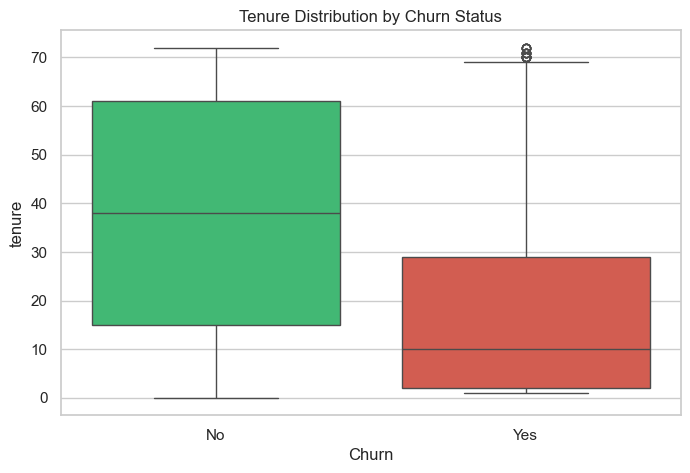

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [17]:
# Task 17 — numerical feature 1 vs Churn
sns.boxplot(data=clean_df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn Status')
plt.show()

print(clean_df.groupby('Churn')['tenure'].describe())

**Observation:** Churned customers have a significantly lower median tenure than retained customers.
**Evidence:** Median tenure for churned customers is **10 months**, whereas median tenure for non-churned customers is **38 months**.
**Possible Explanation:** Customer churn occurs early in the lifecycle; surviving the first year builds brand loyalty.

C:\Users\Areej\AppData\Local\Temp\ipykernel_15956\3556667826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])


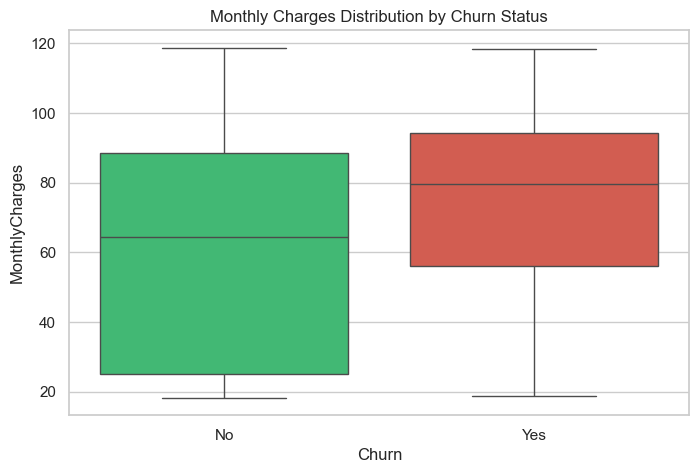

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [18]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

print(clean_df.groupby('Churn')['MonthlyCharges'].describe())

**Observation:** High monthly billing rates strongly correlate with increased churn.
**Evidence:** Churned customers have a higher median monthly bill ($79.65) than retained customers ($64.43).
**Possible Explanation:** High recurring costs place financial pressure on customers, pushing them toward competitors.

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

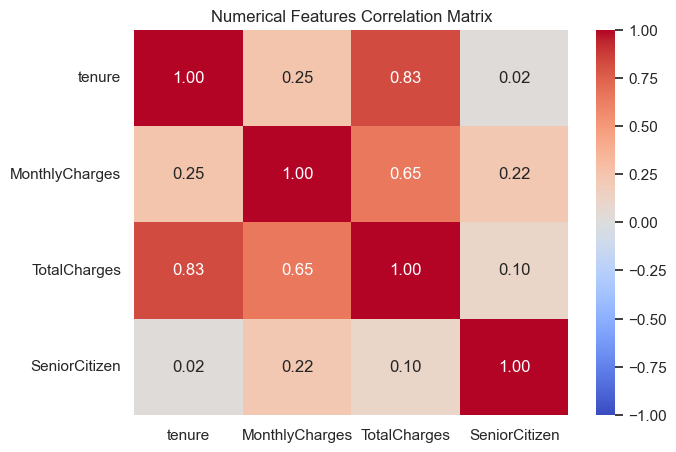

In [19]:
# Task 18 — correlation matrix and heatmap
plt.figure(figsize=(7, 5))
num_vars = clean_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
sns.heatmap(num_vars.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.show()

**Answer 18 (most correlated pairs):**
The strongest correlation exists between `tenure` and `TotalCharges` ($r = 0.83$), followed by `MonthlyCharges` and `TotalCharges` ($r = 0.65$).

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not imply direct causation here because `TotalCharges` is a mathematical derivative ($\text{TotalCharges} \approx \text{tenure} \times \text{MonthlyCharges}$). Including collinear variables like `tenure` and `TotalCharges` together can cause severe multicollinearity issues, inflating model coefficient variances in linear classifiers.

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
`customerID` is a non-predictive primary key that must be removed. No post-hoc data leakage columns (such as `CancellationReason` or `ExitSurveyScore`) exist in this raw dataset.

**Answer 21 (what would go wrong):**
If non-predictive identifier keys or post-hoc leakage features are left in the input features, the model will memorize arbitrary keys or rely on future information. This leads to artificially high validation scores during training, but catastrophic failure when deployed on real unseen customer data.

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | None | **Remove** | Unique primary key string; contains no predictive behavioral signal. |
| gender | Categorical | Feature | **Keep** | Baseline demographic attribute. |
| SeniorCitizen | Binary | Feature | **Keep** | Demographic attribute linked to fixed income and price sensitivity. |
| Partner | Categorical | Feature | **Keep** | Household status influences subscription retention. |
| Dependents | Categorical | Feature | **Keep** | Family structure affects household service stability. |
| tenure | Numerical | Feature | **Keep** | Strong inverse relationship with churn risk. |
| PhoneService | Categorical | Feature | **Keep** | Primary service indicator. |
| MultipleLines | Categorical | Feature | **Keep** | Multi-line add-on service tier. |
| InternetService | Categorical | Feature | **Keep** | Fiber Optic displays strong correlation with customer churn. |
| OnlineSecurity | Categorical | Feature | **Keep** | Security add-on that reduces customer churn rate. |
| OnlineBackup | Categorical | Feature | **Keep** | Data backup add-on service. |
| DeviceProtection | Categorical | Feature | **Keep** | Hardware protection add-on service. |
| TechSupport | Categorical | Feature | **Keep** | Technical support drastically improves customer retention. |
| StreamingTV | Categorical | Feature | **Keep** | Media add-on engagement feature. |
| StreamingMovies | Categorical | Feature | **Keep** | Media add-on engagement feature. |
| Contract | Categorical | Feature | **Keep** | Strongest structural predictor of customer churn. |
| PaperlessBilling | Categorical | Feature | **Keep** | Billing preference indicator. |
| PaymentMethod | Categorical | Feature | **Keep** | Electronic Check payment method correlates with high churn. |
| MonthlyCharges | Numerical | Feature | **Keep** | Primary economic driver for customer churn. |
| TotalCharges | Numerical | Feature | **Keep** | Cumulative billing magnitude (missing entries imputed with 0.0). |
| Churn | Categorical | Target | **Keep** | Target classification label. |

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [20]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Convert TotalCharges to float and impute tenure=0 missing entries
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0.0)

# Drop identifier column
if 'customerID' in clean_df.columns:
    clean_df = clean_df.drop(columns=['customerID'])

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_df to 'clean_churn.csv' successfully!")

Saved clean_df to 'clean_churn.csv' successfully!


# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("--- clean_df Info ---")
clean_df.info()

print("\nMissing Values Count:", clean_df.isnull().sum().sum())
print("Duplicate Rows Count:", clean_df.duplicated().sum())

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: Month-to-month contracts have the highest churn rate by a wide margin.
- Evidence: 42.71% of Month-to-month subscribers churn, compared to 2.83% for Two-year contract holders.
- Interpretation: Securing customers on long-term contracts is the most effective structural lever for churn reduction.

**Finding 2**
- Observation: Fiber Optic internet subscribers experience disproportionately high churn rates.
- Evidence: Fiber Optic churn stands at 41.89%, compared to 18.96% for DSL and 7.40% for no internet.
- Interpretation: Premium pricing or service reliability issues in the Fiber Optic tier drive subscriber dissatisfaction.

**Finding 3**
- Observation: Customer churn is heavily concentrated in the early months of service.
- Evidence: The median tenure of churned customers is 10 months, compared to 38 months for non-churners.
- Interpretation: The first 12 months of customer onboarding are the critical window for proactive intervention.

**Finding 4**
- Observation: Manual payment methods correlate with elevated churn rates.
- Evidence: Customers paying via Electronic Check churn at 45.29%, compared to ~15% for automatic bank/credit payments.
- Interpretation: Manual billing requires active monthly involvement, increasing subscriber awareness of recurring costs.

**Finding 5**
- Observation: Raw string placeholders hidden in numeric columns obscure missing data.
- Evidence: `TotalCharges` contained 11 blank spaces (`" "`) corresponding to new accounts with `tenure = 0`.
- Interpretation: Data auditing requires checking for hidden string placeholders before performing numerical type conversion.

---

**Task 26 — Final Reflection Questions**

1. **What was the most important data-quality issue you found?**
   The presence of empty space strings (`" "`) in `TotalCharges` that disguised missing values and forced the entire column into an `object` data type.

2. **What was the most interesting pattern you discovered?**
   The massive churn difference between Electronic Check payment users (~45%) and automatic payment users (~15%).

3. **Which feature seems most useful for predicting churn?**
   `Contract`, because contract duration creates the primary structural exit barrier for subscribers.

4. **Which feature should probably not be used, and why?**
   `customerID`, because it is a unique primary key that carries no predictive signal and can cause overfitting.

5. **What preprocessing will be required before ML modeling (conceptually — do not implement it)?**
   Categorical encoding (One-Hot / Ordinal Encoding), target binary mapping (`Yes` $\rightarrow 1$, `No` $\rightarrow 0$), numeric scaling (MinMaxScaler / StandardScaler), and target class balancing.

6. **What would you do next if you had another 3 hours?**
   Engineer interaction features (e.g., `MonthlyCharges / tenure` ratios) and build segment-level churn models comparing high-value versus low-value subscribers.

## Bonus Tasks 

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [21]:
# Bonus — optional exploration: Churn across Contract + InternetService
segmented_churn = pd.crosstab(
    [clean_df['Contract'], clean_df['InternetService']], 
    clean_df['Churn'], 
    normalize='index'
) * 100

print("--- Segmented Churn Rate (%) ---")
print(segmented_churn.round(2))

--- Segmented Churn Rate (%) ---
Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78
